<a href="https://colab.research.google.com/github/blagaiulia/BlagaIulia-IA-1-NLP/blob/main/Recenzii_de_filme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Se descarcă setul de date IMDB...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

...

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Se aplică preprocesarea avansată...

=== REZULTATE NAIVE BAYES ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       516
           1       0.82      0.84      0.83       484

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000


=== REZULTATE LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       516
           1       0.82      0.87      0.85       484

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000


Generăm Matricea de Confuzie...


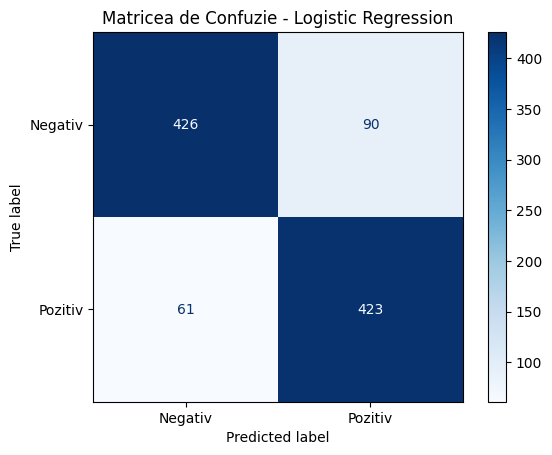


Generăm Graficul Coeficienților...


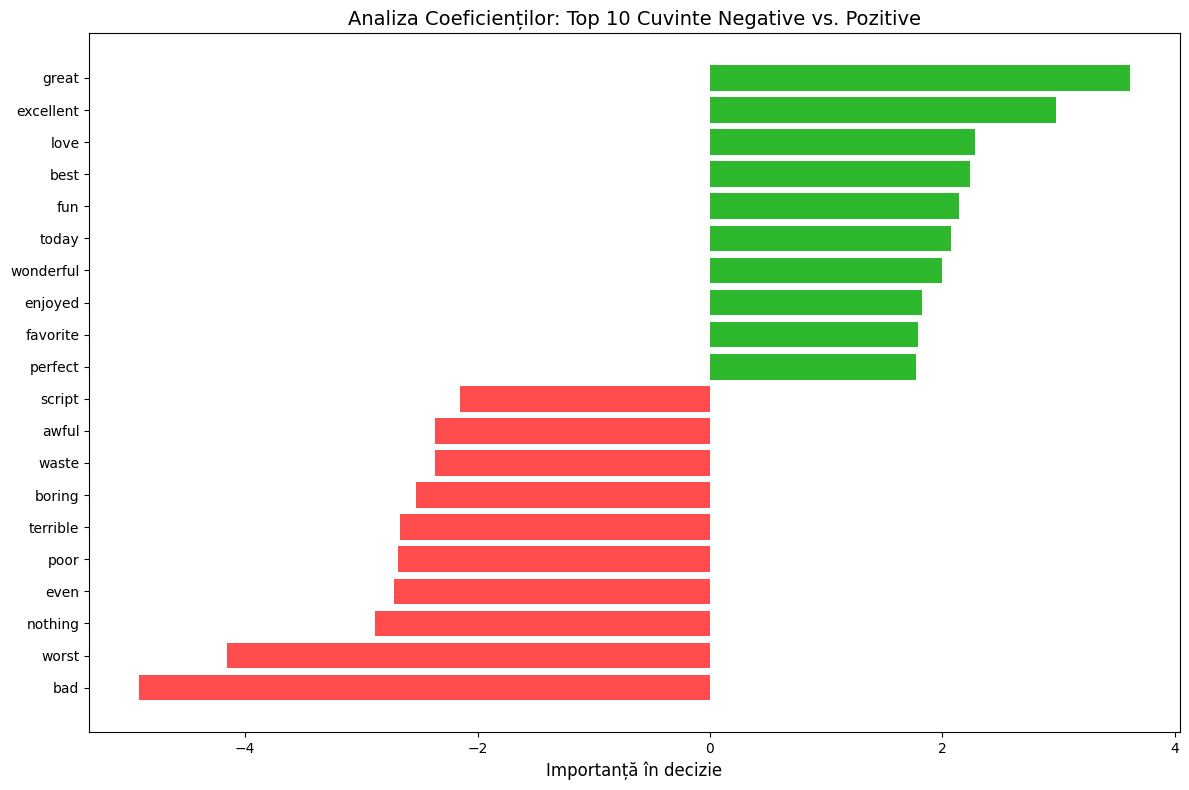

In [ ]:
# INSTALARE SI IMPORTURI
!pip install datasets
from datasets import load_dataset
import pandas as pd
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

# DESCARCARE RESURSE
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

# INCARCARE DATE
print("Se descarcă setul de date IMDB...")
raw_dataset = load_dataset("imdb", split='train')
df = pd.DataFrame(raw_dataset)
df = df.sample(5000, random_state=42)
df = df.rename(columns={'text': 'review'})

# FUNCTIA DE PREPROCESARE AVANSATA
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_advanced(text):
    # Curatare HTML
    text = re.sub(r'<.*?>', '', text)
    # Eliminare simboluri si cifre
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Normalizare (Lowercasing)
    text = text.lower()
    # Tokenizare
    tokens = word_tokenize(text)
    # Stopwords & Lematizare
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(cleaned)

print("Se aplică preprocesarea avansată...")
df['review_curatat'] = df['review'].apply(clean_text_advanced)

# IMPARTIRE DATE
X_train, X_test, y_train, y_test = train_test_split(
    df['review_curatat'], df['label'], test_size=0.2, random_state=42
)

# VECTORIZARE TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ANTRENARE MODELE
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(f"\n=== REZULTATE {name.upper()} ===")
    print(classification_report(y_test, y_pred))

# VIZUALIZARE 1: Matrice de Confuzie
print("\nGenerăm Matricea de Confuzie...")
ConfusionMatrixDisplay.from_estimator(models["Logistic Regression"], X_test_tfidf, y_test,
                                       display_labels=['Negativ', 'Pozitiv'], cmap='Blues')
plt.title('Matricea de Confuzie - Logistic Regression')
plt.show()

# VIZUALIZARE 2: Importanța Cuvintelor (Coeficienți)
print("\nGenerăm Graficul Coeficienților...")
model_final = models["Logistic Regression"]
feature_names = tfidf.get_feature_names_out()
coefs = model_final.coef_.flatten()

top_indices = np.argsort(coefs)[-10:]
bottom_indices = np.argsort(coefs)[:10]
interesting_indices = np.concatenate([bottom_indices, top_indices])

plt.figure(figsize=(12, 8))
colors = ['#ff4d4d' if c < 0 else '#2eb82e' for c in coefs[interesting_indices]]
plt.barh(np.arange(20), coefs[interesting_indices], color=colors)
plt.yticks(np.arange(20), feature_names[interesting_indices])
plt.title("Analiza Coeficienților: Top 10 Cuvinte Negative vs. Pozitive", fontsize=14)
plt.xlabel("Importanță în decizie", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:

def prezice_sentiment(text_nou):
    text_curatat = clean_text_advanced(text_nou)

    text_vectorizat = tfidf.transform([text_curatat])

    predictie = models["Logistic Regression"].predict(text_vectorizat)[0]
    probabilitate = models["Logistic Regression"].predict_proba(text_vectorizat)

    sentiment = "POZITIV" if predictie == 1 else "NEGATIV"
    scor = probabilitate[0][1] if predictie == 1 else probabilitate[0][0]

    print(f"\nRecenzie: {text_nou}")
    print(f"Verdict: {sentiment} (Siguranță: {scor*100:.2f}%)")

prezice_sentiment("This is the worst movie I have ever seen. A complete waste of time and money. The plot was boring and the acting was awful and terrible. Just a horrible experience.")
prezice_sentiment("This movie is an absolute masterpiece! It was perfect, wonderful, and amazing. The acting was excellent and the story was brilliant. Highly recommended for everyone, it is truly the best film ever made!")


Recenzie: This is the worst movie I have ever seen. A complete waste of time and money. The plot was boring and the acting was awful and terrible. Just a horrible experience.
Verdict: NEGATIV (Siguranță: 99.17%)

Recenzie: This movie is an absolute masterpiece! It was perfect, wonderful, and amazing. The acting was excellent and the story was brilliant. Highly recommended for everyone, it is truly the best film ever made!
Verdict: POZITIV (Siguranță: 97.58%)
